In [ ]:
import sys
import os

sys.path.append(os.path.abspath("..")) 
import models

import matplotlib.pyplot as plt
import jax
import jax.numpy as jnp
import jax.random as jr
from models.kuramoto_graph import KuramotoGraph
from models.epidemic import SISGraph

In [2]:
# Suppose G is your KuramotoGraph instance
G = SISGraph(20)

G.positions()
G.distances()
A = G.graphon(k=2, lam=0.5)  # adjacency from graphon

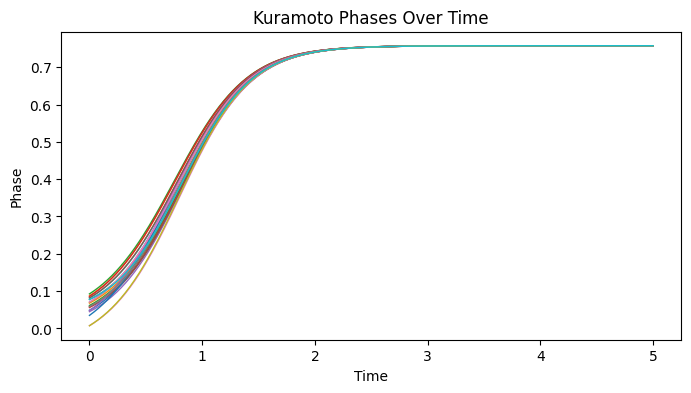

In [5]:
dt = 0.01
T=5

# simulate dynamics
sol = G.simulate(T=T, dt=dt)
plt.figure(figsize=(8,4))
for i in range(sol.ys.shape[1]):
    plt.plot(sol.ts, sol.ys[:, i], lw=1)
plt.xlabel('Time')
plt.ylabel('Phase')
plt.title('Kuramoto Phases Over Time')
plt.show()


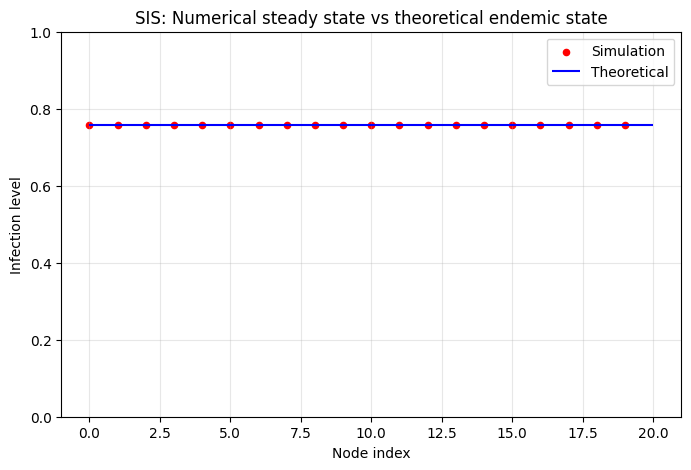

Theoretical endemic u* = 0.7574595212936401
Numerical average = 0.7574584484100342


In [10]:
dx = 2 * jnp.pi / G.n
lambda1 = float(jnp.sum(G.A[0, :])) * dx   # any row sum is fine for circulant A
u_theory = float(jnp.clip(1.0 - G.gamma / (G.beta * lambda1), 0.0, 1.0))


osc = jnp.arange(G.n)

plt.figure(figsize=(8,5))
plt.scatter(osc, sol.ys[-1], s=20, label="Simulation", color="red")
plt.hlines(u_theory, 0, G.n, color='blue', label="Theoretical")
plt.ylim(0, 1)
plt.title("SIS: Numerical steady state vs theoretical endemic state")
plt.xlabel("Node index")
plt.ylabel("Infection level")
plt.legend()
plt.grid(alpha=0.3)
plt.show()

print("Theoretical endemic u* =", u_theory)
print("Numerical average =", float(sol.ys[-1].mean()))
